# Red Noise in Massive Stars

In [1]:
%matplotlib inline
#plt.style.use('/Users/mcantiello/.matplotlib/mesa.mplstyle')


import matplotlib.pyplot as plt
import mesa_reader as mr
import numpy as np
from pylab import *
from math import log10, pi
from matplotlib import rc
#rc('mathtext', default='regular')
import matplotlib as mpl
import matplotlib.tri as tri

import matplotlib.transforms as mtransforms
from matplotlib.ticker import MaxNLocator
from scipy import interpolate
from scipy.interpolate import griddata


from numpy import loadtxt
import pandas as pd 
from matplotlib.patches import Rectangle
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

from Constants import Constants
c=Constants() 

# Define some colors
BLACK      = (0.00,0.00,0.00)
ORANGE     = (0.90,0.60,0.00)
SKY_BLUE   = (0.35,0.70,0.90)
BLUE_GREEN = (0.00,0.60,0.50)
YELLOW     = (0.95,0.90,0.25)
BLUE       = (0.00,0.45,0.70)
VERMILLION = (0.80,0.40,0.00)
RED_PURPLE = (0.80,0.60,0.70)

Constants defined...


In [2]:
####################################################
# Plt Options from Perna, Lazzati & Cantiello 2017 #
####################################################
plt.rcParams['figure.figsize'] = (6,7)
plt.rcParams['font.family'] = ['Times New Roman']
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['axes.titlepad'] = 20 
plt.rcParams['legend.frameon'] = False
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['font.size'] = 16
plt.rcParams['legend.borderpad'] = 0.2
plt.rc('legend', borderpad=0.2, markerscale=15., fancybox=False)
plt.rcParams['legend.labelspacing'] = 0.5
plt.rcParams['legend.handletextpad'] = 0.5
plt.rcParams['legend.handlelength'] = 1
plt.rcParams["legend.framealpha"] = 1.0
####################################################

In [3]:
rsun=6.9598e10
msun=1.9892e33
lsun=3.8418e33
tsun = 5777
G=6.67428e-8 

In [4]:
FIGURES='./figures/'

In [5]:
def find_zams(logl,loglh,model):
    zams=1
    while (loglh[zams] < 1.0*logl[zams]): 
     zams=zams+1
    return zams; 

def find_h(dh,center_h1,model):
    zams=1
    while (center_h1[zams] > (center_h1[1] - dh)): 
     zams=zams+1
    return zams; 
    
def find_tams(center_h1,model):
    tams=1
    while (center_h1[tams] > 0.05): 
     tams=tams+1
    return tams;    

def find_max(a,b,c,d):
    z= [0] * len(a)
    for i in range(0, len(a)):
      z[i]=max(a[i],b[i],c[i],d[i])   
    return z;

def binary(z):  
    for i in range(0, len(z)):
      if z[i] > 0:
         z[i] = 1
      else: 
         z[i] = 0
    return z;

def pbeta(p,b):    # Plasma Beta
    beta= 8*3.1415*p/(b**2.0)
    return beta;

def rossby(vcon,vroteq,hp,req): # Rossby number, defined as Prot/Pcon
    ross =(3.14*req/hp)*(vcon/veq)
    return ross; 
def beq(vcon,rho): # Calculate equipartition Bfield
    b=vcon*(4*3.14*rho)**0.5
    return b;
def char_freq(vcon,hp,req): # Rossby number, defined as Prot/Pcon
    ross =(3.14*req/hp)*(vcon/veq)
    return ross; 

In [6]:
mods = [1.5,1.6,1.7,1.8,1.9, 2.0, 2.2, 2.4, 2.5,2.6, 2.8, 3.0,3.2, 3.4, 3.6 ,3.8, 4.0 ,4.2, 4.4 ,4.6 ,4.8 ,5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25]
hrdlines = [1.5,2.0,2.5,3.0,4.0,5.0,6.0,7.0,9.0,11,13,15,20,25]


/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:47: RuntimeWarning: divide by zero encountered in log10
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/tri/triinterpolate.py:287: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 1]*y +
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/tri/triinterpolate.py:288: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 2])


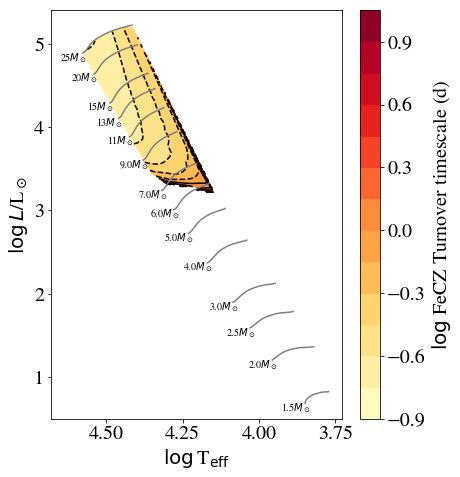

In [7]:
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
    
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver  
    
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(logl[zams])
      gzams.append(logg[zams])
      tzams.append(logt[zams])
      x.append(logt[zams:tams])
      y.append(logl[zams:tams])
      z.append(turnover_FeCZ[zams:tams]) 
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    z=np.log10(z/3600/24)
  
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k')
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap="YlOrRd")
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\log$ FeCZ Turnover timescale (d)')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        plt.plot(logt[zams:tams],logl[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,logl[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
        
    #ax.text(4.5,1.1,'Max equipartition B-field',fontsize=22)
    #ax.text(4.5,0.85,'in envelope convection zones (CZs)',fontsize=22)
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, L$/L$_\odot$')
    ax.set_xlim([4.68,3.73])
    ax.set_ylim([0.5,5.4])
    plt.savefig("turnover_FeCZ.pdf")

DIR = '/Users/mcantiello/Dropbox (Personal)/work/astars/'
read_models(DIR,mods)



/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:47: RuntimeWarning: divide by zero encountered in log10
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/tri/triinterpolate.py:287: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 1]*y +
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/tri/triinterpolate.py:288: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 2])


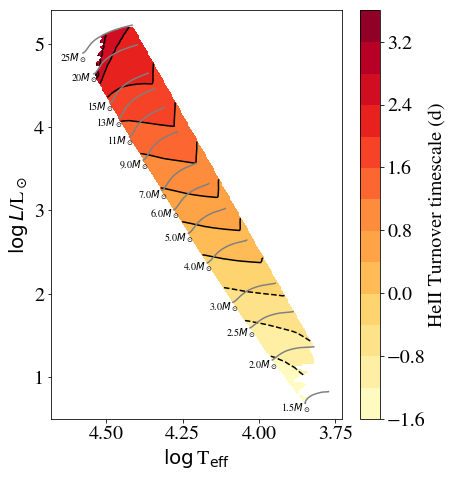

In [8]:
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
    
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver  
    
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(logl[zams])
      gzams.append(logg[zams])
      tzams.append(logt[zams])
      x.append(logt[zams:tams])
      y.append(logl[zams:tams])
      z.append(turnover_HeII[zams:tams]) 
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    z=np.log10(z/3600/24)
  
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k')
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap="YlOrRd")
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'HeII Turnover timescale (d)')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        plt.plot(logt[zams:tams],logl[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,logl[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
        
    #ax.text(4.5,1.1,'Max equipartition B-field',fontsize=22)
    #ax.text(4.5,0.85,'in envelope convection zones (CZs)',fontsize=22)
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, L$/L$_\odot$')
    ax.set_xlim([4.68,3.73])
    ax.set_ylim([0.5,5.4])
    plt.savefig("turnover_HeII.pdf")

DIR = '/Users/mcantiello/Dropbox (Personal)/work/astars/'
read_models(DIR,mods)




/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:47: RuntimeWarning: divide by zero encountered in log10
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/tri/triinterpolate.py:287: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 1]*y +
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/tri/triinterpolate.py:288: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 2])


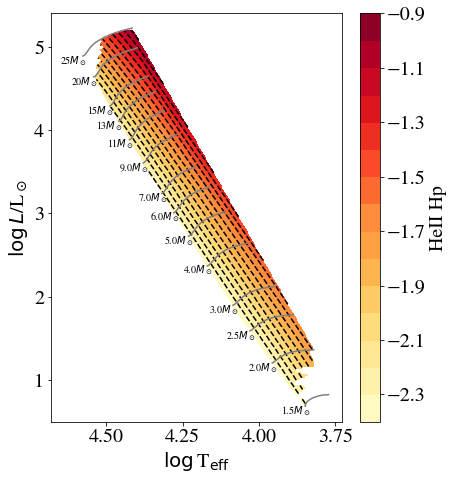

In [9]:
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
    
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver  
    
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(logl[zams])
      gzams.append(logg[zams])
      tzams.append(logt[zams])
      x.append(logt[zams:tams])
      y.append(logl[zams:tams])
      z.append(HeII_hp_aver[zams:tams]) 
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    z=np.log10(z/rsun)
  
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k')
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap="YlOrRd")
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'HeII Hp')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        plt.plot(logt[zams:tams],logl[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,logl[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
        
    #ax.text(4.5,1.1,'Max equipartition B-field',fontsize=22)
    #ax.text(4.5,0.85,'in envelope convection zones (CZs)',fontsize=22)
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, L$/L$_\odot$')
    ax.set_xlim([4.68,3.73])
    ax.set_ylim([0.5,5.4])
    plt.savefig("Hp_HeII.pdf")

DIR = '/Users/mcantiello/Dropbox (Personal)/work/astars/'
read_models(DIR,mods)





/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:47: RuntimeWarning: divide by zero encountered in true_divide
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/tri/triinterpolate.py:287: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 1]*y +
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/tri/triinterpolate.py:288: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 2])


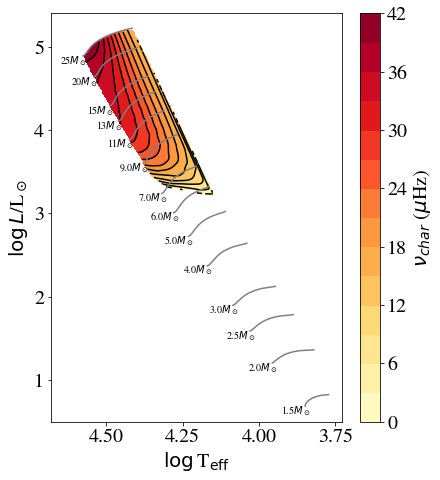

In [10]:
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
    
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver  
    
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(logl[zams])
      gzams.append(logg[zams])
      tzams.append(logt[zams])
      x.append(logt[zams:tams])
      y.append(logl[zams:tams])
      z.append(turnover_FeCZ[zams:tams]) 
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>
  
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k')
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap="YlOrRd")
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        plt.plot(logt[zams:tams],logl[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,logl[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
        
    #ax.text(4.5,1.1,'Max equipartition B-field',fontsize=22)
    #ax.text(4.5,0.85,'in envelope convection zones (CZs)',fontsize=22)
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, L$/L$_\odot$')
    ax.set_xlim([4.68,3.73])
    ax.set_ylim([0.5,5.4])
    plt.savefig("freq_FeCZ.pdf")

DIR = '/Users/mcantiello/Dropbox (Personal)/work/astars/'
read_models(DIR,mods)




/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:49: RuntimeWarning: divide by zero encountered in true_divide
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/tri/triinterpolate.py:287: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 1]*y +
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/tri/triinterpolate.py:288: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 2])


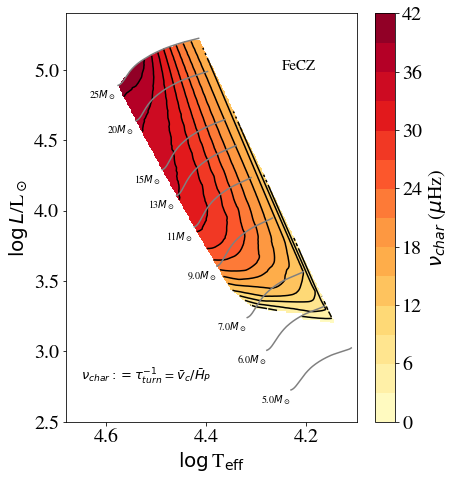

In [11]:
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25]
hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,25]
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
    
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver  
    
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(logl[zams])
      gzams.append(logg[zams])
      tzams.append(logt[zams])
      x.append(logt[zams:tams])
      y.append(logl[zams:tams])
      z.append(turnover_FeCZ[zams:tams]) 
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>
  
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k')
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap="YlOrRd")
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        plt.plot(logt[zams:tams],logl[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,logl[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
        
    ax.text(4.65,2.8,r'$\nu_{char} := \tau_{turn}^{-1}$ = $\bar{v}_{c}/\bar{H}_{P}$',fontsize=13)
    ax.text(4.25,5,'FeCZ',fontsize=15)
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, L$/L$_\odot$')
    ax.set_xlim([4.68,4.1])
    ax.set_ylim([2.5,5.4])
    
    plt.savefig("freq_FeCZ_zoom.pdf")

        
DIR = '/Users/mcantiello/Dropbox (Personal)/work/astars/'
read_models(DIR,mods)





/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:58: RuntimeWarning: divide by zero encountered in true_divide
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/tri/triinterpolate.py:287: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 1]*y +
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/tri/triinterpolate.py:288: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 2])


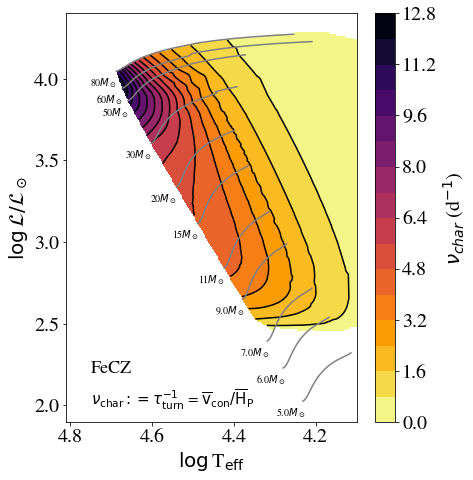

In [12]:
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,40,60,80]
hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,25,40,60,80]

ell_sun=(5777)**4.0/(274*100)  


def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
         
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver  
      
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
    
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(logt[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      z.append(turnover_FeCZ[zams:]) 
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    z=(1/(z/86400))  # in d^-1 86400
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k')
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='inferno_r') #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ (d$^{-1}$)')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:tams],ell[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
        
 #   ax.text(4.7,2.8,r'$\nu_{char} := \tau_{turn}^{-1}$ = $\bar{v}_{c}/\bar{H}_{P}$',fontsize=13)
 #   ax.text(4.7,3.3,'FeCZ',fontsize=15)
    ax.text(4.75,2.0,r'$\nu_{\rm char} := \tau_{\rm turn}^{-1}$ = $\overline{ \rm v}_{\rm con}/\overline{H}_{\rm P}$',fontsize=15)
    ax.text(4.75,2.2,'FeCZ',fontsize=18)
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, \mathcal{L} / \mathcal{L}_\odot$')
    #ax.set_xlim([4.76,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_xlim([4.81,4.1])
    ax.set_ylim([1.9,4.4])
    
    
    plt.savefig(FIGURES+"freq_FeCZ_zoom_days.pdf",bbox_inches='tight')

        
DIR = '/Users/mcantiello/Dropbox (Personal)/work/astars/'

DIR = '/Users/mcantiello/Dropbox (Personal)/work/red_noise/Z0.02_CORE/'
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,23,24,30,50,60,80]
hrdlines = [5.0,6.0,7.0,9.0,11,15,20,30,50,60,80]

read_models(DIR,mods)





/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/contour.py:960: UserWarning: The following kwargs were not used by contour: 'setlims'
  s)


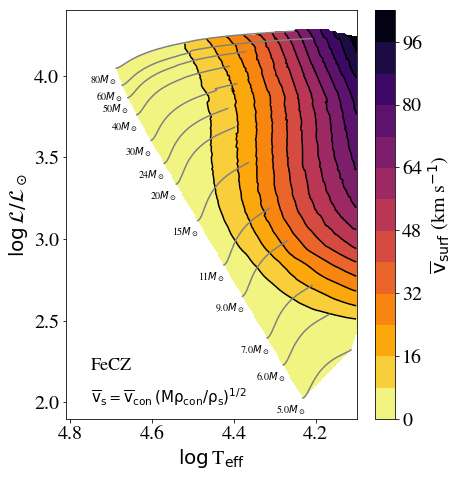

In [13]:
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,40,60,80]
hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,25,40,60,80]



ell_sun=(5777)**4.0/(274*100)  


def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(max_surf_velocity[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='inferno_r',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\overline{\rm v}_{\rm surf}$ (km s$^{-1}$)')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:tams],ell[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
        
    ax.text(4.75,2.0,r'$\overline{\rm v}_{\rm s}$ = $\overline{\rm v}_{\rm con} \, (M \rho_{\rm con}/\rho_{\rm s})^{1/2}$',fontsize=15)
    ax.text(4.75,2.2,'FeCZ',fontsize=18)
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, \mathcal{L} / \mathcal{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
    
    plt.savefig(FIGURES+"vsurf_FeCZ.pdf",bbox_inches='tight')

        
DIR = '/Users/mcantiello/Dropbox (Personal)/work/astars/'
DIR = '/Users/mcantiello/Dropbox (Personal)/work/red_noise/Z0.02/'
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,23,24,40,30,50,60,80]
hrdlines = [5.0,6.0,7.0,9.0,11,15,20,24,30,40,50,60,80]
read_models(DIR,mods)





## FeCZ Convective velocities

/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:41: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/contour.py:960: UserWarning: The following kwargs were not used by contour: 'setlims'
  s)


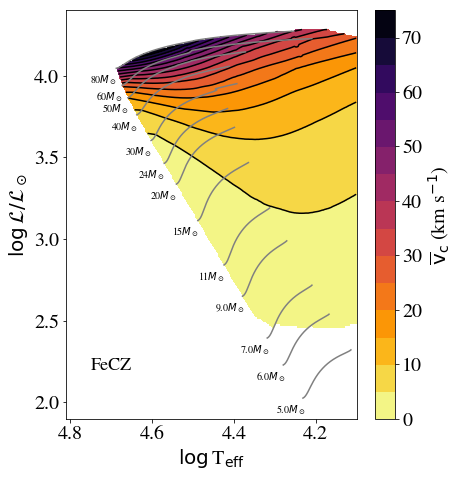

In [14]:
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,40,60,80]
hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,25,40,60,80]



ell_sun=(5777)**4.0/(274*100)  


def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver 
      alpha_mlt=1.5 
      vc=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(vc[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='inferno_r',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\overline{\rm v}_{\rm c}$ (km s$^{-1}$)')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:tams],ell[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
        
    #ax.text(4.78,2.1,r'v$_{\rm s}$ = $\bar{\rm v}_{\rm FeCZ} \, (M \rho_{\rm FeCZ}/\rho_{\rm s})^{1/2}$',fontsize=14)
    ax.text(4.75,2.2,'FeCZ',fontsize=18)
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, \mathcal{L} / \mathcal{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
    
    plt.savefig(FIGURES+"vc_FeCZ.pdf",bbox_inches='tight')

        
DIR = '/Users/mcantiello/Dropbox (Personal)/work/astars/'
DIR = '/Users/mcantiello/Dropbox (Personal)/work/red_noise/Z0.02/'
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,23,24,40,30,50,60,80]
hrdlines = [5.0,6.0,7.0,9.0,11,15,20,24,30,40,50,60,80]
read_models(DIR,mods)





### From Velocity to Luminosity Fluctuations
This is from Kjeldsen and Bedding 1995, but including the effect of N cells (which somehow I don't think is included in their original formula. Surprisingly)

$\frac{d L}{L} \approx \frac{(V_{surf}/ m s^{-1})}{T_{eff}/5777 K} \, \frac{1}{\sqrt{N}}  $17.7 ppm

18ppm = 1.086 $\mu$mag

/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:34: RuntimeWarning: divide by zero encountered in true_divide
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/tri/triinterpolate.py:287: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 1]*y +
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/tri/triinterpolate.py:288: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 2])
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/contour.py:960: UserWarning: The following kwargs were not used by contour: 'setlims'
  s)


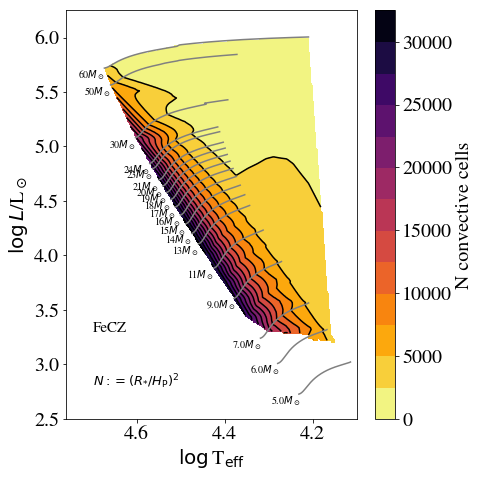

In [15]:
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,40,60]#,80]
hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,25,40,60]#,80]
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      stellar_radius=10**h.log_R
      
      v_FeCZ_surf=h.v_FeCZ_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver 
    
      n_cells=(stellar_radius*rsun/FeCZ_hp_aver)**2.0
      #print(FeCZ_hp_aver/rsun)
      
    
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(logl[zams])
      gzams.append(logg[zams])
      tzams.append(logt[zams])
      x.append(logt[zams:tams])
      y.append(logl[zams:tams])
      z.append(n_cells[zams:tams]) 
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    #z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='inferno_r',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'N convective cells')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        plt.plot(logt[zams:tams],logl[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,logl[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
        
    ax.text(4.7,2.8,r'$N := (R_{*}/H_{\rm P})^2$',fontsize=13)
    ax.text(4.7,3.3,'FeCZ',fontsize=15)
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, L$/L$_\odot$')
    ax.set_xlim([4.76,4.1])
    ax.set_ylim([2.5,6.25])
    
    plt.savefig("Ncells_FeCZ.pdf")

        
DIR = '/Users/mcantiello/Dropbox (Personal)/work/astars/'

DIR = '/Users/mcantiello/Dropbox (Personal)/work/red_noise/Z0.02/'
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,23,24,30,50,60]
hrdlines = [5.0,6.0,7.0,9.0,11,13,14,15,16,17,18,19,20,21,23,24,30,50,60]

read_models(DIR,mods)





/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:41: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:43: RuntimeWarning: divide by zero encountered in true_divide
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/tri/triinterpolate.py:287: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 1]*y +
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/tri/triinterpolate.py:288: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 2])
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/contour.py:960: UserWarning: The following kwargs were not used by contour: 'setlims'
  s)


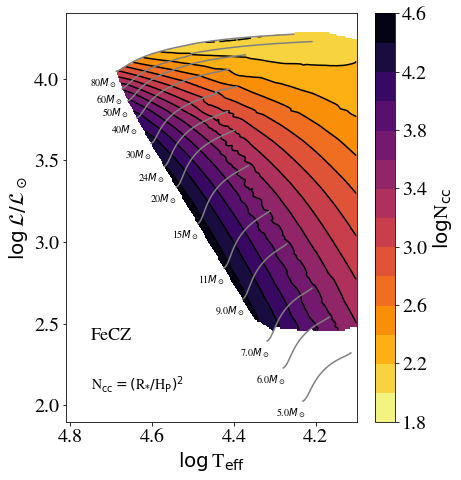

In [16]:
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,40,60,80]
hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,25,40,60,80]



ell_sun=(5777)**4.0/(274*100)  


def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver 
      alpha_mlt=1.5 
      vc=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      stellar_radius=10**h.log_R  
      n_cells=(stellar_radius*rsun/FeCZ_hp_aver)**2.0
      n_cells=np.log10(n_cells)
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(n_cells[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    #z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='inferno_r',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\log $N$_{\rm cc}$')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:tams],ell[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
        
    ax.text(4.75,2.1,r'N$_{\rm cc} = ($R$_{*}/$H$_{\rm P})^2$',fontsize=14)
    ax.text(4.75,2.4,'FeCZ',fontsize=18)
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, \mathcal{L} / \mathcal{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
    
    plt.savefig(FIGURES+"Ncells_FeCZ.pdf",bbox_inches='tight')

        
DIR = '/Users/mcantiello/Dropbox (Personal)/work/astars/'
DIR = '/Users/mcantiello/Dropbox (Personal)/work/red_noise/Z0.02/'
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,23,24,40,30,50,60,80]
hrdlines = [5.0,6.0,7.0,9.0,11,15,20,24,30,40,50,60,80]
read_models(DIR,mods)





## Velocity fluctuations multiplied by $1/\sqrt{N}$

/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:41: RuntimeWarning: divide by zero encountered in true_divide
/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:51: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/contour.py:960: UserWarning: The following kwargs were not used by contour: 'setlims'
  s)


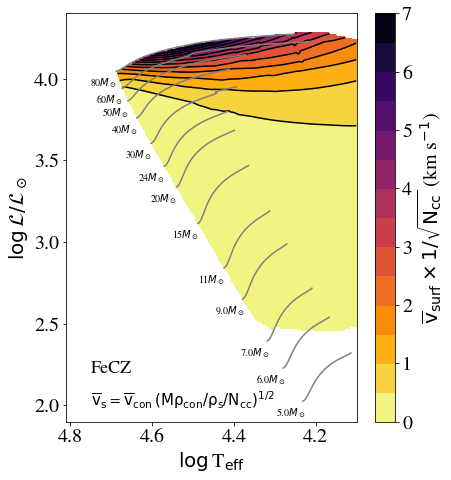

In [17]:
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,40,60,80]
hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,25,40,60,80]



ell_sun=(5777)**4.0/(274*100)  


def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver 
      stellar_radius=10**h.log_R  
      n_cells=(stellar_radius*rsun/FeCZ_hp_aver)**2.0  
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_surf_velocity=max_surf_velocity/(n_cells)**0.5 
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
    
      alpha_mlt=1.5 
      vc=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vc=vc/(n_cells)**0.5 
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(vc[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='inferno_r',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\overline{\rm v}_{\rm surf} \times 1/\sqrt{\rm N_{\rm cc}}$ (km s$^{-1}$)')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:tams],ell[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
        
    ax.text(4.75,2.0,r'$\overline{\rm v}_{\rm s}$ = $\overline{\rm v}_{\rm con} \, (M \rho_{\rm con}/\rho_{\rm s}/{\rm N}_{\rm cc})^{1/2}}$',fontsize=15)
    ax.text(4.75,2.2,'FeCZ',fontsize=18)
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, \mathcal{L} / \mathcal{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
    
    plt.savefig(FIGURES+"vsurf_ncells_FeCZ.pdf",bbox_inches='tight')

        
DIR = '/Users/mcantiello/Dropbox (Personal)/work/astars/'
DIR = '/Users/mcantiello/Dropbox (Personal)/work/red_noise/Z0.02/'
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,23,24,40,30,50,60,80]
hrdlines = [5.0,6.0,7.0,9.0,11,15,20,24,30,40,50,60,80]
read_models(DIR,mods)





/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:40: RuntimeWarning: divide by zero encountered in true_divide
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/contour.py:960: UserWarning: The following kwargs were not used by contour: 'setlims'
  s)


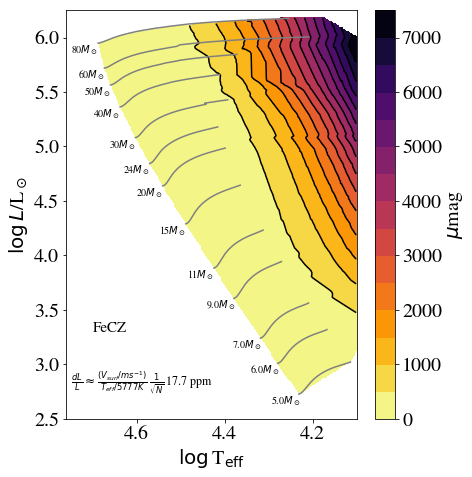

In [18]:
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25]#,40]#,80]
hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,25]#,40]# ,80]
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      stellar_radius=10**h.log_R
        
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
        
    
      n_cells=(stellar_radius*rsun/FeCZ_hp_aver)**2.0
      dl= (max_surf_velocity/100)/((10**logt)/5777)
      dl=dl/(n_cells**0.5) # Account for cancelling effects
      dl=dl*17.7*1.086 # Transform in muMag   
      dl=dl/10
    
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(logl[zams])
      gzams.append(logg[zams])
      tzams.append(logt[zams])
      x.append(logt[zams:])
      y.append(logl[zams:])
      z.append(dl[zams:]) 
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    #z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 16, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 16, cmap='inferno_r',setlims=True) #cmap="YlOrRd") #vmin=0,vmax=1000
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\mu$mag')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        plt.plot(logt[zams:tams],logl[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,logl[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
        
    #ax.text(4.7,2.8,r'$dL/L$',fontsize=13)
    ax.text(4.75,2.8,r'$\frac{dL}{L} \approx \frac{(V_{surf}/ m s^{-1})}{T_{eff}/5777 K} \, \frac{1}{\sqrt{N}} \, $17.7 ppm',fontsize=12)
    ax.text(4.7,3.3,'FeCZ',fontsize=15)
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, L$/L$_\odot$')
    ax.set_xlim([4.76,4.1])
    ax.set_ylim([2.5,6.25])
    
    plt.savefig("dl_FeCZ.pdf")

        
DIR = '/Users/mcantiello/Dropbox (Personal)/work/astars/'
DIR = '/Users/mcantiello/Dropbox (Personal)/work/red_noise/Z0.02/'

mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,23,24,40,30,50,60,80]
hrdlines = [5.0,6.0,7.0,9.0,11,15,20,24,30,40,50,60,80]

read_models(DIR,mods)





/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:34: RuntimeWarning: divide by zero encountered in true_divide
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/contour.py:960: UserWarning: The following kwargs were not used by contour: 'setlims'
  s)


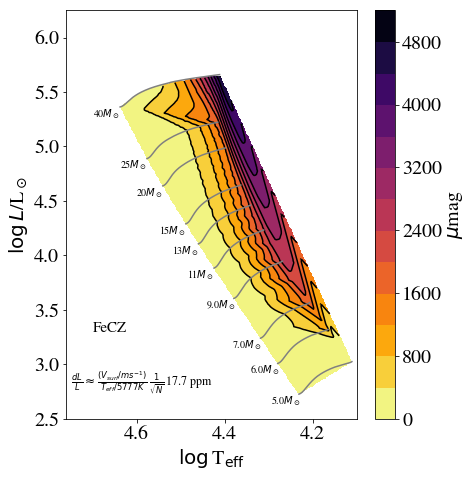

In [19]:
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,40]#,80]
hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,25,40]# ,80]
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      stellar_radius=10**h.log_R
      
      v_FeCZ_surf=h.v_FeCZ_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver 
    
      n_cells=(stellar_radius*rsun/FeCZ_hp_aver)**2.0
      dl= (v_FeCZ_surf/100)/((10**logt)/5777)
      dl=dl/(n_cells**0.5) # Account for cancelling effects
      dl=dl*17.7*1.086 # Transform in muMag   
      
    
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(logl[zams])
      gzams.append(logg[zams])
      tzams.append(logt[zams])
      x.append(logt[zams:tams])
      y.append(logl[zams:tams])
      z.append(dl[zams:tams]) 
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    #z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='inferno_r',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\mu$mag')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        plt.plot(logt[zams:tams],logl[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,logl[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
        
    #ax.text(4.7,2.8,r'$dL/L$',fontsize=13)
    ax.text(4.75,2.8,r'$\frac{dL}{L} \approx \frac{(V_{surf}/ m s^{-1})}{T_{eff}/5777 K} \, \frac{1}{\sqrt{N}} \, $17.7 ppm',fontsize=12)
    ax.text(4.7,3.3,'FeCZ',fontsize=15)
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, L$/L$_\odot$')
    ax.set_xlim([4.76,4.1])
    ax.set_ylim([2.5,6.25])
    
    plt.savefig("dl_FeCZ.pdf")

        
DIR = '/Users/mcantiello/Dropbox (Personal)/work/astars/'
read_models(DIR,mods)





## Mach Number 


/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:36: RuntimeWarning: divide by zero encountered in true_divide
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/contour.py:960: UserWarning: The following kwargs were not used by contour: 'setlims'
  s)


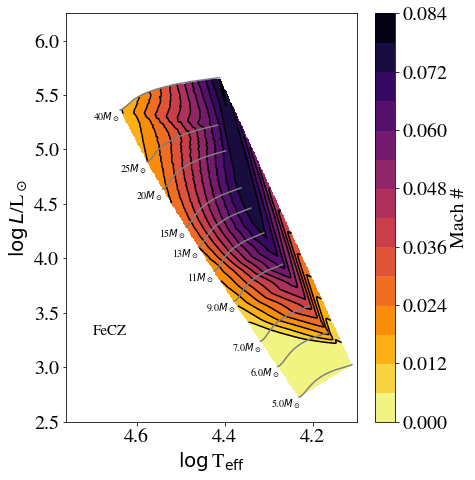

In [20]:
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,40]#,80]
hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,25,40]# ,80]
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      stellar_radius=10**h.log_R
      
      v_FeCZ_surf=h.v_FeCZ_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver 
        
      mach_fe=h.mach_FeCZ_aver_ahp  
    
      n_cells=(stellar_radius*rsun/FeCZ_hp_aver)**2.0
      dl= (v_FeCZ_surf/100)/((10**logt)/5777)
      dl=dl/(n_cells**0.5) # Account for cancelling effects
      dl=dl*17.7*1.086 # Transform in muMag   
      
    
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(logl[zams])
      gzams.append(logg[zams])
      tzams.append(logt[zams])
      x.append(logt[zams:tams])
      y.append(logl[zams:tams])
      z.append(mach_fe[zams:tams]) 
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    #z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='inferno_r',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'Mach #')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        plt.plot(logt[zams:tams],logl[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,logl[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
        
    #ax.text(4.7,2.8,r'$dL/L$',fontsize=13)
  #  ax.text(4.75,2.8,r'$\frac{dL}{L} \approx \frac{(V_{surf}/ m s^{-1})}{T_{eff}/5777 K} \, \frac{1}{\sqrt{N}} \, $17.7 ppm',fontsize=12)
    ax.text(4.7,3.3,'FeCZ',fontsize=15)
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, L$/L$_\odot$')
    ax.set_xlim([4.76,4.1])
    ax.set_ylim([2.5,6.25])
    
    plt.savefig("mach_FeCZ.pdf")

        
DIR = '/Users/mcantiello/Dropbox (Personal)/work/astars/'
read_models(DIR,mods)





/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:54: RuntimeWarning: divide by zero encountered in true_divide


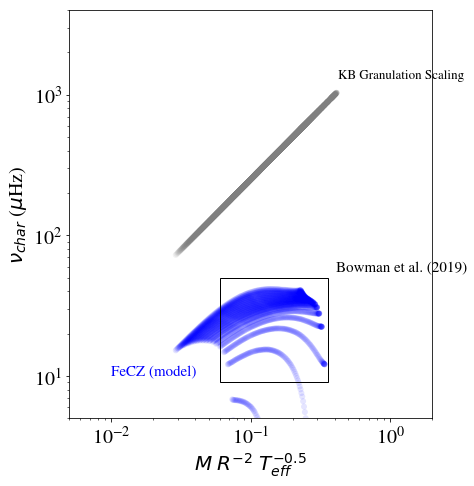

In [21]:
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25]

def read_models(location,lis):
    x = []
    y = []
    z = []
  

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []
    

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      radius = 10**h.log_R
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff
      teff = 10**logt 
      mass = h.star_mass
    
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver  
    
      KB_scaling = mass*((teff/tsun)**(-0.5))*((radius))**(-2.0)  
      KB_scaling_predicted_frequency =  2500*mass*((teff/tsun)**(-0.5))*((radius))**(-2.0) 
        
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
   
      x.append(KB_scaling[zams:tams])
      y.append(turnover_FeCZ[zams:tams])
      z.append(KB_scaling_predicted_frequency[zams:tams])  
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))
    y=((1/y)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>
  
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    

    ax.scatter(x,y , c='blue', alpha=0.1, edgecolors='none')
    ax.scatter(x,z,c='gray', alpha=0.1, edgecolors='none')
    ax.set_yscale('log')
    ax.set_xscale('log')
    
    ax.add_patch(Rectangle((0.06, 9), 0.3, 41, fill=None, alpha=1))
    
    ax.text(0.42,1300,r'KB Granulation Scaling',fontsize=13)  
    ax.text(0.01,10,'FeCZ (model)',fontsize=15,color='blue')
    ax.text(0.41,55,'Bowman et al. (2019)',fontsize=15)
    ax.set_xlabel(r'$M \;R^{-2}\; T_{eff}^{-0.5}$')
    ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    ax.set_xlim([0.005,2])
    ax.set_ylim([5,4000])
    
    
    
    plt.savefig("KB_scaling.pdf")

        
DIR = '/Users/mcantiello/Dropbox (Personal)/work/astars/'
read_models(DIR,mods)






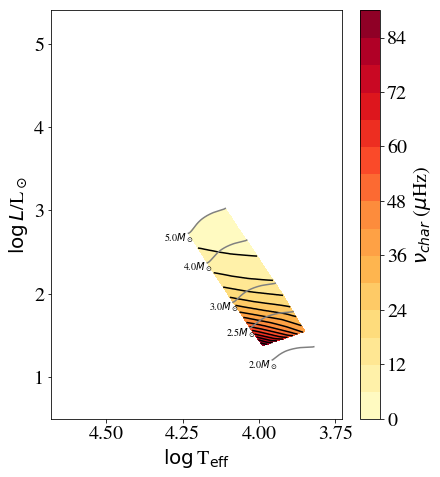

In [22]:
mods = [2.2, 2.4, 2.5,2.6, 2.8, 3.0,3.2, 3.4, 3.6 ,3.8, 4.0 ,4.2, 4.4 ,4.6 ,4.8 ,5.0]
hrdlines = [2.0,2.5,3.0,4.0,5.0]



def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
    
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
        
    
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(logl[zams])
      gzams.append(logg[zams])
      tzams.append(logt[zams])
      x.append(logt[zams:tams])
      y.append(logl[zams:tams])
      z.append(turnover_HeII[zams:tams]) 
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

  
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k')
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap="YlOrRd")
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        plt.plot(logt[zams:tams],logl[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,logl[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
        
    #ax.text(4.5,1.1,'Max equipartition B-field',fontsize=22)
    #ax.text(4.5,0.85,'in envelope convection zones (CZs)',fontsize=22)
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, L$/L$_\odot$')
    ax.set_xlim([4.68,3.73])
    ax.set_ylim([0.5,5.4])
    plt.savefig("freq_HeII.pdf")

DIR = '/Users/mcantiello/Dropbox (Personal)/work/astars/'
read_models(DIR,mods)





# Subsurface Convection
## Comparing to Bowman et al. 2020 Data

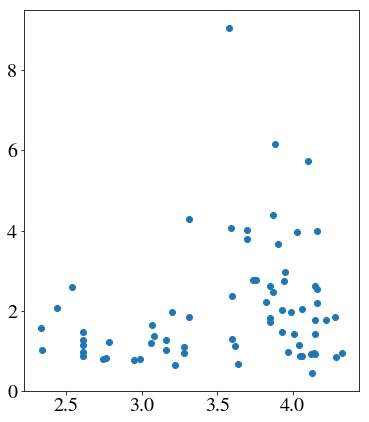

In [37]:
DIR = '/Users/mcantiello/Dropbox (Personal)/work/red_noise/Z0.02_CORE/'
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,30,40,50,60,80,100,120]
hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,25,30,40,60,80,120]

file='data_bowman_all.csv'
    
import pandas as pd 
df = pd.read_csv(file, sep=',')           # Read csv file into a panda dataframe


logl_data=df['logL']
logl_data=[float(item) for item in logl_data]

logt_data=df['logTeff']
logt_data=[float(item) for item in logt_data]

vmacro_data=df['vmacro']
vmacro_data=[float(item) for item in vmacro_data]


l=df['nuchar']                            # Read nuchar column 
nuchar=[i.split('±')[0] for i in l]       # Split elements (value  ±  error) and take value
nuchar_data = [float(item) for item in nuchar] # Turn into floats

l=df['alpha0']                            # Read nuchar column 
alpha0=[i.split('±')[0] for i in l]       # Split elements (value  ±  error) and take value
alpha0_data = [float(item) for item in alpha0] # Turn into floats




logl_data=np.array(logl_data)              # Turn lists into arrays 
logt_data=np.array(logt_data)
vmacro_data=np.array(vmacro_data)
nuchar_data=np.array(nuchar_data)
alpha0_data=np.array(alpha0_data)

#print(nuchar)
plt.scatter(logl_data,nuchar_data)

#print(df['nuchar'].str.extract('(\d+)'))

### Compare Macroturbulence Data to Convective Velocity in FeCZ (this is similar to Grassitelli et al. 2015)

/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:40: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:42: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:43: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:41: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/contour.py:960: UserWarning: The following kwargs were not used by contour: 'setlims'
  s)
/Users/mcantiello/.local/lib/python3.5/site-packages/matplotlib/collections.py:902: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


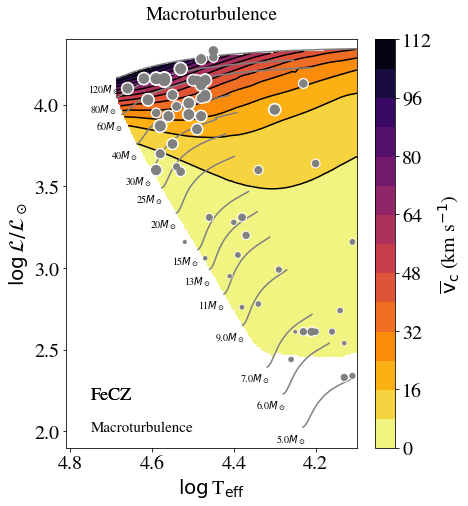

In [38]:
ell_sun=(5777)**4.0/(274*100)  

def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
    
      alpha_mlt=1.5 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
   #   print(max_conv_velocity)
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(max_conv_velocity[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='inferno_r',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\overline{\rm v}_{\rm c}$ (km s$^{-1}$)')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:tams],ell[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
        
    #ax.text(4.78,2.1,r'v$_{\rm s}$ = $\bar{\rm v}_{\rm FeCZ} \, (M \rho_{\rm FeCZ}/\rho_{\rm s})^{1/2}$',fontsize=14)
    ax.text(4.75,2.2,'FeCZ',fontsize=18)    
    ax.text(4.75,2.0,r'Macroturbulence',fontsize=15)
    
    ax.scatter(logt_data,logl_data,s=vmacro_data*1.8,c='white',zorder=3)
    ax.scatter(logt_data,logl_data,s=vmacro_data,c='gray',zorder=3)
    ax.text(4.75,2.2,'FeCZ',fontsize=18)
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, \mathcal{L} / \mathcal{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
    
    plt.title(r'Macroturbulence')
    plt.savefig(FIGURES+"vc_FeCZ_macroturbulence.pdf",bbox_inches='tight')

read_models(DIR,mods)


### Compare Frequency of Red Noise to Turnover Frequency in FeCZ

In [ ]:

ell_sun=(5777)**4.0/(274*100)  
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
         
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver  
      
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
    
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(logt[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      z.append(turnover_FeCZ[zams:]) 
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    z=(1/(z*2*3.14/86400))  # in d^-1 86400
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k')
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='inferno_r') #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ (d$^{-1}$)')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:tams],ell[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
        
 #   ax.text(4.7,2.8,r'$\nu_{char} := \tau_{turn}^{-1}$ = $\bar{v}_{c}/\bar{H}_{P}$',fontsize=13)
 #   ax.text(4.7,3.3,'FeCZ',fontsize=15)
    ax.text(4.75,2.0,r'$\nu_{\rm char} := (2 \pi \tau_{\rm turn})^{-1}$ = $\overline{ \rm v}_{\rm con}/\overline{H}_{\rm P}$',fontsize=15)
    ax.text(4.75,2.2,'FeCZ',fontsize=18)
    ax.scatter(logt_data,logl_data,s=nuchar_data*18,c='white',zorder=3)
    ax.scatter(logt_data,logl_data,s=nuchar_data*10,c='gray',zorder=3)
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, \mathcal{L} / \mathcal{L}_\odot$')
    #ax.set_xlim([4.76,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_xlim([4.81,4.1])
    ax.set_ylim([1.9,4.4])
    
    plt.title(r'Characteristic Frequency ($\nu_{\rm char}$)')
    plt.savefig(FIGURES+"freq_FeCZ_data.pdf",bbox_inches='tight')

    
read_models(DIR,mods)

### Compare Photometric Amplitude to Convective velocities in FeCZ

In [ ]:
ell_sun=(5777)**4.0/(274*100)  

def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
    
      alpha_mlt=1.5 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
   #   print(max_conv_velocity)
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(max_conv_velocity[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='inferno_r',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\overline{\rm v}_{\rm c}$ (km s$^{-1}$)')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:tams],ell[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
    ax.text(4.75,2.2,'FeCZ',fontsize=18)    
    ax.text(4.75,2.0,r'Photometric Amplitude ($\alpha_0$)',fontsize=15)
    
    ax.scatter(logt_data,logl_data,s=alpha0_data/15,c='white',zorder=3)
    ax.scatter(logt_data,logl_data,s=alpha0_data/30,c='gray',zorder=3)
    
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, \mathcal{L} / \mathcal{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
    plt.title(r'Photometric Amplitude $\alpha_0$')
    plt.savefig(FIGURES+"vc_FeCZ_rednoise.pdf",bbox_inches='tight')

read_models(DIR,mods)


### FeCZ Flux vs Photometric Amplitude
$\frac{dL}{L}\propto \frac{{\rm F}_{\rm c}}{\rm F_{*}}$
or
$\frac{dL}{L}\propto \frac{{\rm F}_{\rm c}\, {\rm M}_{\rm c}}{\rm F_{*}}$


In [ ]:
ell_sun=(5777)**4.0/(274*100)  
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
    
      alpha_mlt=1.6 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
   #   print(max_conv_velocity)
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
      flux=h.FeCZ_Fc_max  
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(flux[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='inferno_r',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'F$_{\rm c}$')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:tams],ell[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
    ax.text(4.75,2.2,'FeCZ',fontsize=18)    
    ax.text(4.75,2.0,r'Photometric Amplitude ($\alpha_0$)',fontsize=15)
    
    ax.scatter(logt_data,logl_data,s=alpha0_data/15,c='white',zorder=3)
    ax.scatter(logt_data,logl_data,s=alpha0_data/30,c='gray',zorder=3)
    
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, \mathcal{L} / \mathcal{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
    plt.title(r'Photometric Amplitude $\alpha_0$')
    plt.savefig(FIGURES+"flux_FeCZ_rednoise.pdf",bbox_inches='tight')

 
read_models(DIR,mods)


In [ ]:
ell_sun=(5777)**4.0/(274*100)  

def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
    
      alpha_mlt=1.6 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
   #   print(max_conv_velocity)
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
      mach_FeCZ_aver_ahp=h.mach_FeCZ_aver_ahp # Convective Mach number top 1Hp of FeCZ
      flux=h.FeCZ_Fc_max*mach_FeCZ_aver_ahp   # Multiplied by Max Fc/F*
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(flux[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='inferno_r',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'F$_{\rm c}$')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:tams],ell[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
    ax.text(4.75,2.2,'FeCZ',fontsize=18)    
    ax.text(4.75,2.0,r'Photometric Amplitude ($\alpha_0$)',fontsize=15)
    
    ax.scatter(logt_data,logl_data,s=alpha0_data/15,c='white',zorder=3)
    ax.scatter(logt_data,logl_data,s=alpha0_data/30,c='gray',zorder=3)
    
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, \mathcal{L} / \mathcal{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
    plt.title(r'Photometric Amplitude $\alpha_0$')
    plt.savefig(FIGURES+"flux_FeCZ_mach_rednoise.pdf",bbox_inches='tight')

        

read_models(DIR,mods)


### Compare Photometric Amplitude to Surface velocities from FeCZ (assuming IGWs)

In [ ]:
ell_sun=(5777)**4.0/(274*100)  


def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(max_surf_velocity[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='inferno_r',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\overline{\rm v}_{\rm surf}$ (km s$^{-1}$)')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:tams],ell[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
        
    ax.text(4.75,2.0,r'$\overline{\rm v}_{\rm s}$ = $\overline{\rm v}_{\rm con} \, (M \rho_{\rm con}/\rho_{\rm s})^{1/2}$',fontsize=15)
    ax.text(4.75,2.2,'FeCZ',fontsize=18)
    ax.scatter(logt_data,logl_data,s=alpha0_data/15,c='white',zorder=3)
    ax.scatter(logt_data,logl_data,s=alpha0_data/30,c='gray',zorder=3)
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, \mathcal{L} / \mathcal{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
    plt.title(r'Photometric Amplitude $\alpha_0$')
    plt.savefig(FIGURES+"vsurf_FeCZ_data.pdf",bbox_inches='tight')


read_models(DIR,mods)





### Surface Velocity Fluctuations Weighted by Cell Number vs Amplitude Photometric Fluctuations

In [ ]:
ell_sun=(5777)**4.0/(274*100)  

def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver 
      stellar_radius=10**h.log_R  
      n_cells=(stellar_radius*rsun/FeCZ_hp_aver)**2.0  
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_surf_velocity=max_surf_velocity/(n_cells)**0.5 
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
    
      alpha_mlt=1.5 
      vc=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vc=vc/(n_cells)**0.5 
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(vc[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='inferno_r',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\overline{\rm v}_{\rm surf} \times 1/\sqrt{\rm N_{\rm cc}}$ (km s$^{-1}$)')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:tams],ell[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
        
    ax.text(4.75,2.0,r'$\overline{\rm v}_{\rm s}$ = $\overline{\rm v}_{\rm con} \, (M \rho_{\rm con}/\rho_{\rm s}/{\rm N}_{\rm cc})^{1/2}}$',fontsize=15)
    ax.text(4.75,2.2,'FeCZ',fontsize=18)
    
    ax.scatter(logt_data,logl_data,s=alpha0_data/15,c='white',zorder=3)
    ax.scatter(logt_data,logl_data,s=alpha0_data/30,c='gray',zorder=3)
    
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, \mathcal{L} / \mathcal{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
    
    plt.title(r'Photometric Amplitude $\alpha_0$')
    plt.savefig(FIGURES+"vsurf_ncells_FeCZ_data.pdf",bbox_inches='tight')

        

read_models(DIR,mods)


# Core Convection

In [ ]:
DIR = '/Users/mcantiello/Dropbox (Personal)/work/red_noise/Z0.02_CORE/'
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,30,40,50,60,80,100,120]
hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,25,30,40,60,80,120]

# Used for Spectroscopic HRD 
ell_sun=(5777)**4.0/(274*100)  


In [ ]:
ell_sun=(5777)**4.0/(274*100)  

def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
         
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver  
      turnover_core=h.turnover_core
      v_aver_core=h.v_aver_core
      rho_aver_core=h.rho_aver_core
      v_aver_ahp_core = h.v_aver_ahp_core   # Values calculated in the top alpha_mlt * Hp of the core
      hp_core_top = h.hp_core_top  
      turnover_core_hp =  hp_core_top / v_aver_ahp_core
      #print(turnover_core_hp/86400)
        
        
      flux=rho_aver_core*v_aver_core**3.0
      #print(turnover_core)
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
    
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(logt[zams])
      x.append(logt[zams:tams])
      y.append(ell[zams:tams])
      z.append(turnover_core_hp[zams:tams]) 
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    z=(1/(z*2*3.14/86400))  # in d^-1 86400
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k')
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='inferno_r') #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ (d$^{-1}$)')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    
    mask=[]
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:tams],ell[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        mask.append([logt[tams],ell[tams]]) # To patch region of interpolation outside tams 
    # Patch contour region outside tams
    # print(mask)    
    patches = []   
    polygon = matplotlib.patches.Polygon(mask, closed=True,fill=True, color='white')
    patches.append(polygon)
    coll = PatchCollection(patches, zorder=2,color='white')
    ax.add_collection(coll) 
        
        
 #   ax.text(4.7,2.8,r'$\nu_{char} := \tau_{turn}^{-1}$ = $\bar{v}_{c}/\bar{H}_{P}$',fontsize=13)
 #   ax.text(4.7,3.3,'FeCZ',fontsize=15)
    ax.text(4.77,2.0,r'$\nu_{\rm char}=(2 \pi \tau_{\rm turn})^{-1}$ ',fontsize=15)
    ax.text(4.77,2.2,'Convective Core',fontsize=18)
    ax.scatter(logt_data,logl_data,s=nuchar_data*18,c='white',zorder=3)
    ax.scatter(logt_data,logl_data,s=nuchar_data*10,c='gray',zorder=3)
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, \mathcal{L} / \mathcal{L}_\odot$')
    #ax.set_xlim([4.76,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_xlim([4.81,4.1])
    ax.set_ylim([1.9,4.4])
    
    plt.title(r'Characteristic Frequency ($\nu_{\rm char}$)')
    plt.savefig(FIGURES+"freq_core_data_days.pdf",bbox_inches='tight')

        

read_models(DIR,mods)

### In $\mu$Hz

In [ ]:
ell_sun=(5777)**4.0/(274*100)  

def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
         
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver  
      turnover_core=h.turnover_core
      v_aver_core=h.v_aver_core
      rho_aver_core=h.rho_aver_core
    
      v_aver_ahp_core = h.v_aver_ahp_core   # Values calculated in the top alpha_mlt * Hp of the core
      hp_core_top = h.hp_core_top  
      turnover_core_hp =  hp_core_top / v_aver_ahp_core
        
      hz=1/(2*3.14*turnover_core_hp) # To match definition of Bowman et al. 
      muHz=hz*1e6                     # (alpha= 1.6 ito account for alpha_mixing length, since we calculated turnover timescales as alpha*<Hp>/<vconv> 
      flux=rho_aver_core*v_aver_core**3.0
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
    
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(logt[zams])
      x.append(logt[zams:tams])
      y.append(ell[zams:tams])
      z.append(muHz[zams:tams]) 
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
   
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k')
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='inferno_r') #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    mask=[]
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:tams],ell[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        mask.append([logt[tams],ell[tams]]) # To patch region of interpolation outside tams 
    # Patch contour region outside tams
    # print(mask)    
    patches = []   
    polygon = matplotlib.patches.Polygon(mask, closed=True,fill=True, color='white')
    patches.append(polygon)
    coll = PatchCollection(patches, zorder=2,color='white')
    ax.add_collection(coll) 


 #   ax.text(4.7,2.8,r'$\nu_{char} := \tau_{turn}^{-1}$ = $\bar{v}_{c}/\bar{H}_{P}$',fontsize=13)
 #   ax.text(4.7,3.3,'FeCZ',fontsize=15)
    ax.text(4.77,2.0,r'$\nu_{\rm char}=(2 \pi \tau_{\rm turn})^{-1}$ ',fontsize=15)
    ax.text(4.77,2.2,'Convective Core',fontsize=18)
    ax.scatter(logt_data,logl_data,s=nuchar_data*18,c='white',zorder=3)
    ax.scatter(logt_data,logl_data,s=nuchar_data*10,c='gray',zorder=3)
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, \mathcal{L} / \mathcal{L}_\odot$')
    #ax.set_xlim([4.76,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_xlim([4.81,4.1])
    ax.set_ylim([1.9,4.4])
    
   

    
    plt.title(r'Characteristic Frequency ($\nu_{\rm char}$)')
    plt.savefig(FIGURES+"freq_core_data_hz.pdf",bbox_inches='tight')

 
read_models(DIR,mods)





In [ ]:
ell_sun=(5777)**4.0/(274*100)  
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
    
      alpha_mlt=1.5 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
        
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
   #   print(max_conv_velocity)
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
    
      v_aver_core=h.v_aver_core
      rho_aver_core=h.rho_aver_core
      
      rho_aver_ahp_core=h.rho_aver_ahp_core
      v_aver_ahp_core=h.v_aver_ahp_core  
      mach_aver_ahp_core=h.mach_aver_ahp_core
        
      flux_ahp=rho_aver_ahp_core*v_aver_ahp_core**3.0  # Flux in the top hp of the convective core
      flux_IGW_ahp=flux_ahp*mach_aver_ahp_core         # Assume IGWs are mostly driven in the top Hp
        
      flux_average=rho_aver_core*v_aver_core**3.0     # Average Flux in the convective core 
      flux_IGW_average=flux_average*mach_aver_ahp_core 
        
      v_aver_core=v_aver_core 
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:tams])
      y.append(ell[zams:tams])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(flux_IGW_ahp[zams:tams])
      #flux_IGW_ahp[tams:]=1  
      #z.append(flux_IGW_ahp[tams:])  
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    #z=np.log10(z)
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='inferno_r',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'F$_{\rm c}$')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    mask=[]
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:tams],ell[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        mask.append([logt[tams],ell[tams]]) # To patch region of interpolation outside tams 
    # Patch contour region outside tams
    # print(mask)    
    patches = []   
    polygon = matplotlib.patches.Polygon(mask, closed=True,fill=True, color='white')
    patches.append(polygon)
    coll = PatchCollection(patches, zorder=2,color='white')
    ax.add_collection(coll) 
    
    ax.text(4.77,2.2,'Convective Core',fontsize=18)    
    ax.text(4.77,2.0,r'F$_{\rm C, IGW} = $F$_{\rm C}\, $M ',fontsize=17)
    
    ax.scatter(logt_data,logl_data,s=alpha0_data/15,c='white',zorder=3)
    ax.scatter(logt_data,logl_data,s=alpha0_data/30,c='gray',zorder=3)
    
    ax.set_xlabel(r'$\log\, $T$_{\rm eff}$')
    ax.set_ylabel(r'$\log\, \mathcal{L} / \mathcal{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
    plt.title(r'Photometric Amplitude $\alpha_0$')
    plt.savefig(FIGURES+"flux_IGW_ahp_core_rednoise_data.pdf",bbox_inches='tight')

        

read_models(DIR,mods)
